# Basic Statistics - Descriptive Analytics and Data Visualization



In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In this step, essential Python libraries are imported.

Pandas is used for data manipulation and analysis.
NumPy is used for numerical operations.
Matplotlib is used for creating visualizations such as histograms, box plots, and bar charts.

These libraries form the foundation for performing data analysis in Python.

In [4]:
# Load dataset
df = pd.read_csv(r"/content/sales_data_with_discounts.csv")

# Display first 5 rows
df.head()

,Date,Day,SKU,City,Volume,BU,Brand,Model,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
0,01-04-2021,Thursday,M01,C,15,Mobiles,RealU,RU-10,12100,181500,11.654820,21153.498820,160346.501180
1,01-04-2021,Thursday,M02,C,10,Mobiles,RealU,RU-9 Plus,10100,101000,11.560498,11676.102961,89323.897039
2,01-04-2021,Thursday,M03,C,7,Mobiles,YouM,YM-99,16100,112700,9.456886,10657.910157,102042.089843
3,01-04-2021,Thursday,M04,C,6,Mobiles,YouM,YM-99 Plus,20100,120600,6.935385,8364.074702,112235.925298
4,01-04-2021,Thursday,M05,C,3,Mobiles,YouM,YM-98,8100,24300,17.995663,4372.946230,19927.053770


The dataset is loaded using the pandas read_csv() function.

The head() function is used to display the first five rows of the dataset,
which helps in understanding the structure, columns, and sample data.

This step ensures that the dataset is successfully loaded and ready for analysis.

In [5]:
# Basic information
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


,Volume,Avg Price,Total Sales Value,Discount Rate (%),Discount Amount,Net Sales Value
count,450.000000,450.000000,450.000000,450.000000,450.000000,450.000000
mean,5.066667,10453.433333,33812.835556,15.155242,3346.499424,30466.336131
std,4.231602,18079.904840,50535.074173,4.220602,4509.902963,46358.656624
min,1.000000,290.000000,400.000000,5.007822,69.177942,326.974801
25%,3.000000,465.000000,2700.000000,13.965063,460.459304,2202.208645
50%,4.000000,1450.000000,5700.000000,16.577766,988.933733,4677.788059
75%,6.000000,10100.000000,53200.000000,18.114718,5316.495427,47847.912852
max,31.000000,60100.000000,196400.000000,19.992407,25738.022194,179507.479049


The info() function provides details about the dataset such as column names, data types,
and the presence of missing values.

The describe() function generates summary statistics for numerical columns,
including mean, minimum, maximum, and quartile values.

This step helps in gaining an initial understanding of the dataset and identifying
any data quality issues.

In [6]:
# Select numerical columns
num_cols = df.select_dtypes(include=['int64', 'float64'])

# Calculate statistics
mean_values = num_cols.mean()
median_values = num_cols.median()
mode_values = num_cols.mode().iloc[0]
std_values = num_cols.std()

print("Mean:\n", mean_values)
print("\nMedian:\n", median_values)
print("\nMode:\n", mode_values)
print("\nStandard Deviation:\n", std_values)

Mean:
 Volume                   5.066667
Avg Price            10453.433333
Total Sales Value    33812.835556
Discount Rate (%)       15.155242
Discount Amount       3346.499424
Net Sales Value      30466.336131
dtype: float64

Median:
 Volume                  4.000000
Avg Price            1450.000000
Total Sales Value    5700.000000
Discount Rate (%)      16.577766
Discount Amount       988.933733
Net Sales Value      4677.788059
dtype: float64

Mode:
 Volume                   3.000000
Avg Price              400.000000
Total Sales Value    24300.000000
Discount Rate (%)        5.007822
Discount Amount         69.177942
Net Sales Value        326.974801
Name: 0, dtype: float64

Standard Deviation:
 Volume                   4.231602
Avg Price            18079.904840
Total Sales Value    50535.074173
Discount Rate (%)        4.220602
Discount Amount       4509.902963
Net Sales Value      46358.656624
dtype: float64


In this step, descriptive statistical measures are calculated for numerical columns.

Mean represents the average value of each column.
Median represents the middle value when data is sorted.
Mode represents the most frequently occurring value.
Standard deviation measures how spread out the values are from the mean.

Insights:
These statistical measures help in understanding the distribution and behavior of the data.
If mean and median differ significantly, it may indicate skewness.
A high standard deviation suggests high variability in the data.

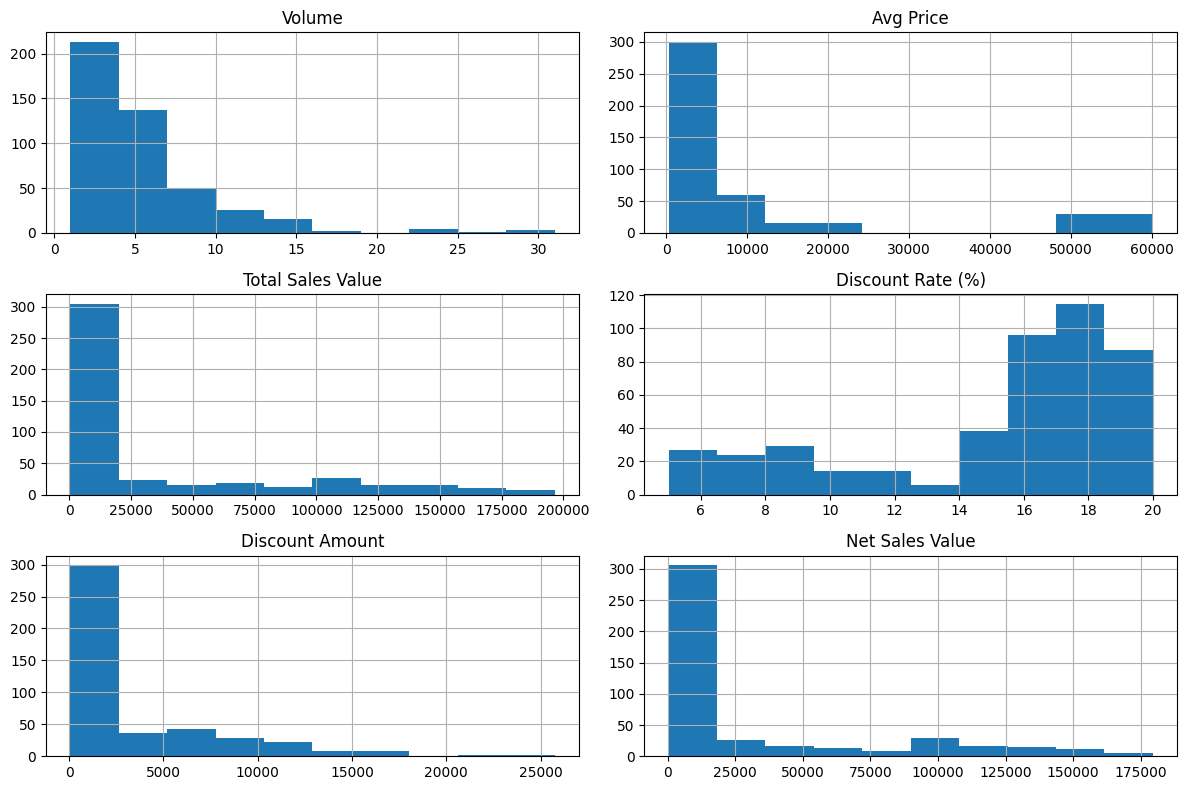

In [7]:
# Plot histograms
num_cols.hist(figsize=(12, 8))
plt.tight_layout()
plt.show()

Histograms are used to visualize the distribution of numerical data.

Each bar represents the frequency of values within a specific range.
This helps in identifying patterns such as normal distribution, skewness, and concentration of values.

Insights:
Some variables may show symmetric distribution, while others may be skewed.
Skewed distributions indicate that values are unevenly distributed.
Histograms also help in detecting extreme values or unusual patterns.

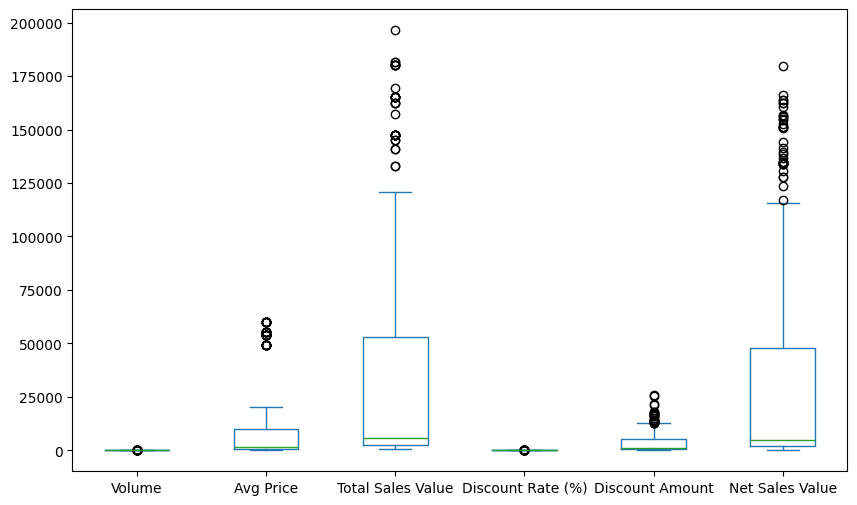

In [8]:
# Box plot
num_cols.plot(kind='box', figsize=(10, 6))
plt.show()

Box plots are used to visualize the spread and distribution of numerical data.

They display quartiles, median, and potential outliers.
Outliers are values that are significantly different from the rest of the data.

Insights:
Box plots help identify extreme values and data variability.
If many outliers are present, it may affect analysis and model performance.
They also provide a quick summary of data distribution.

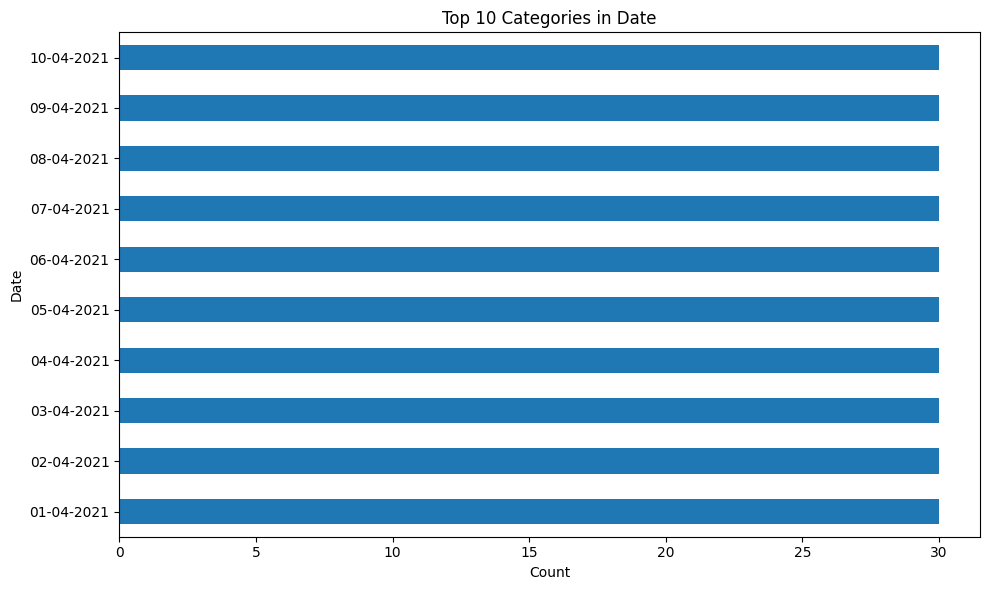

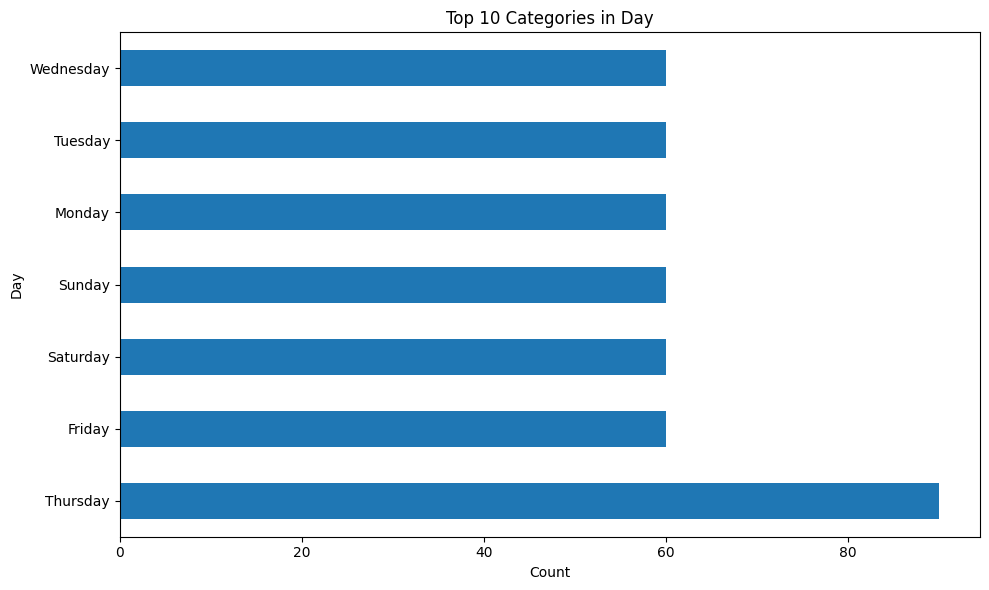

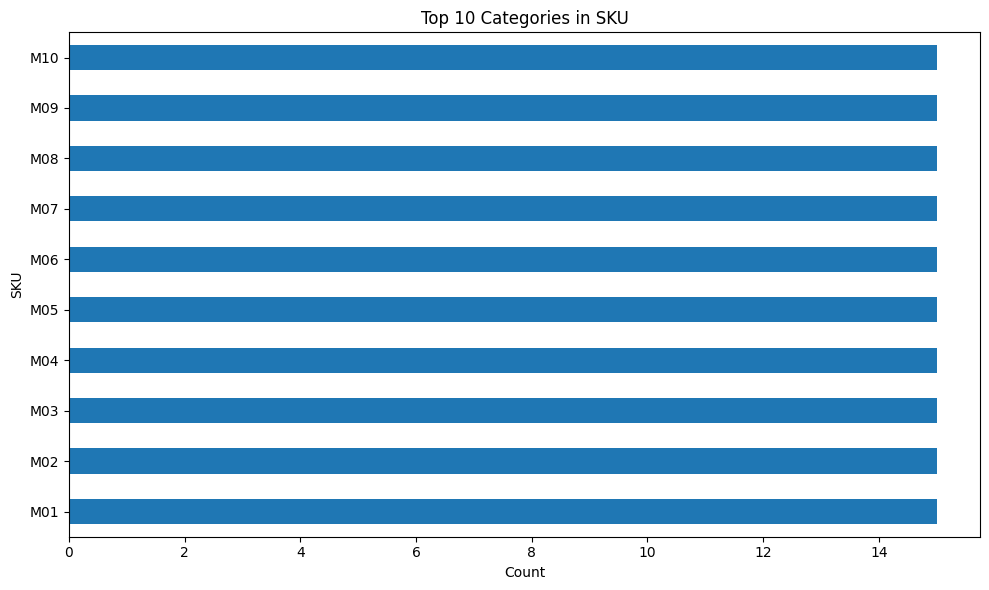

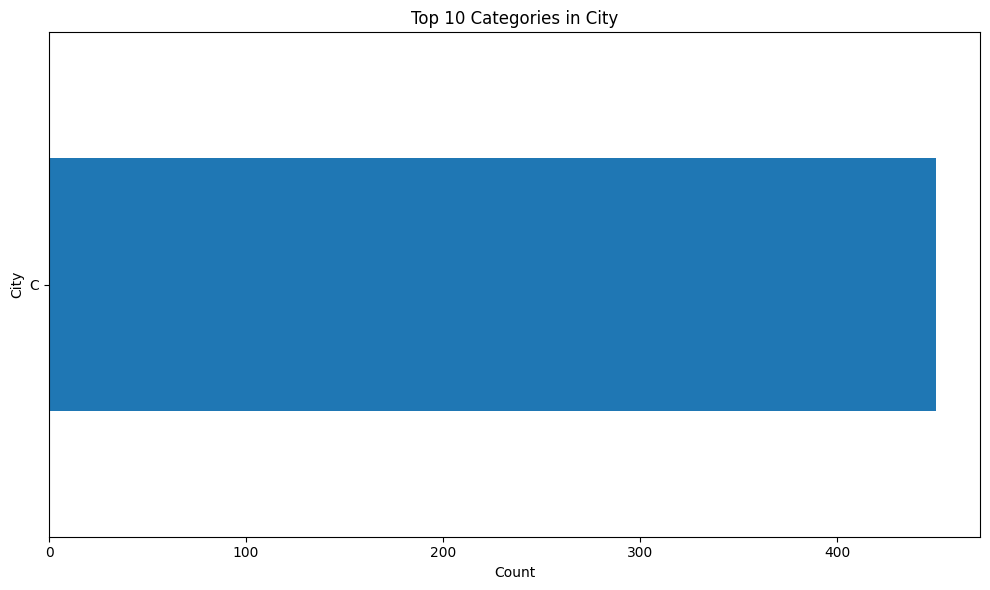

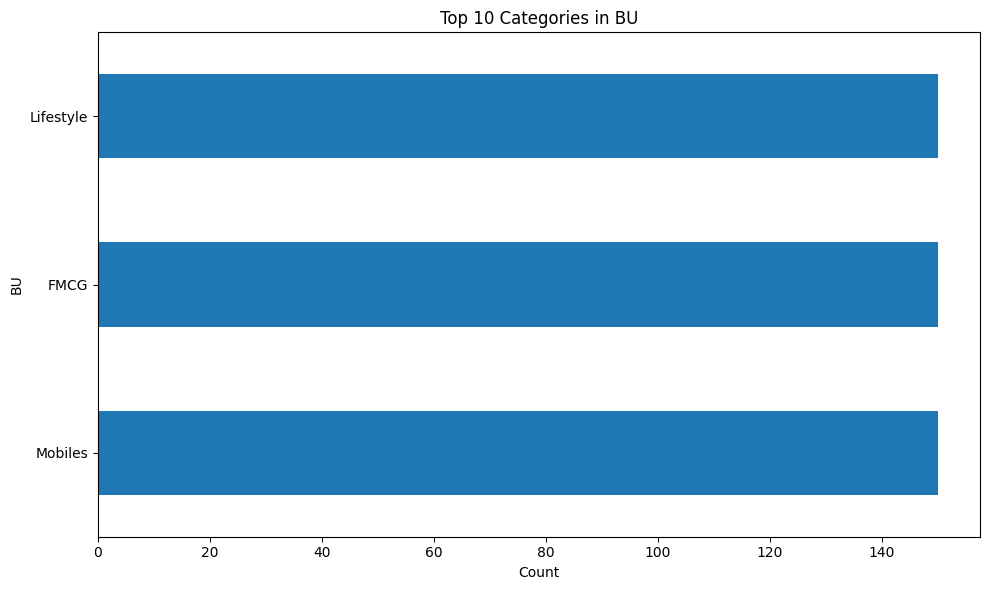

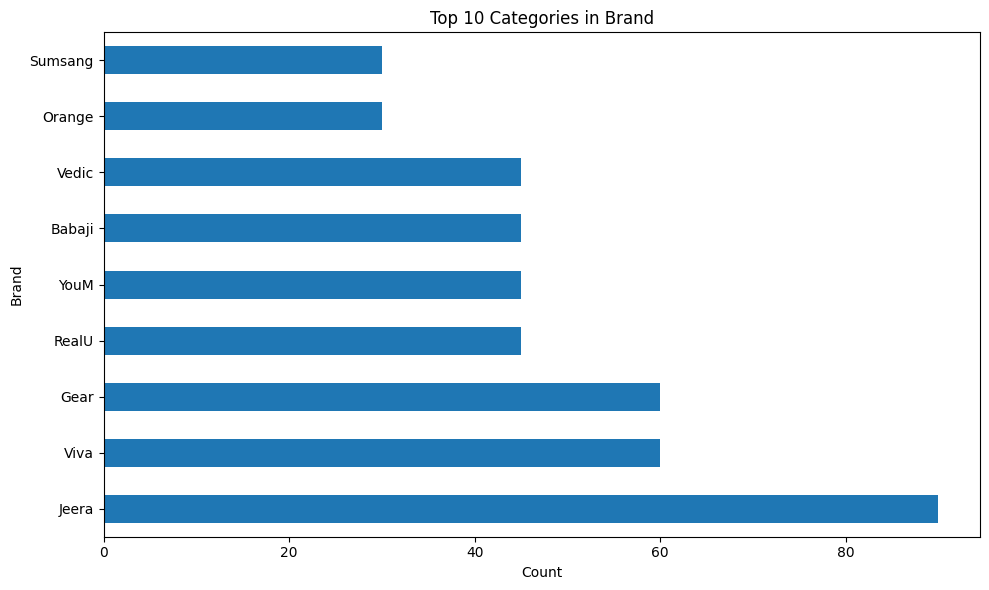

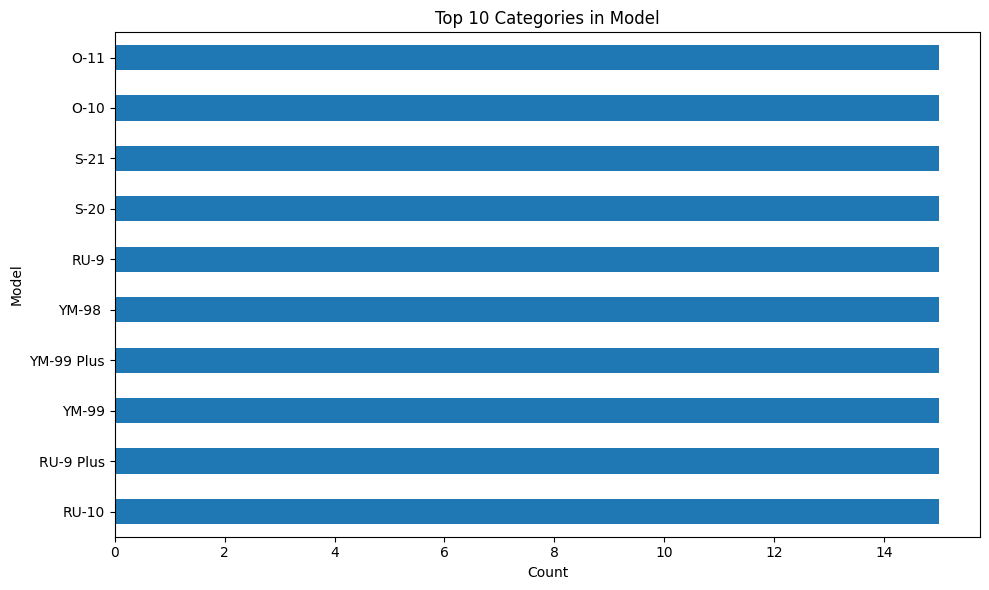

In [9]:
# Select categorical columns
cat_cols = df.select_dtypes(include=['object'])

for col in cat_cols:
    top_values = df[col].value_counts().head(10)

    plt.figure(figsize=(10, 6))
    top_values.plot(kind='barh')

    plt.title(f"Top 10 Categories in {col}")
    plt.xlabel("Count")
    plt.ylabel(col)

    plt.tight_layout()
    plt.show()

In this step, categorical variables are analyzed using bar charts.

Since categorical columns may contain many unique values, plotting all categories
can make the graph cluttered and difficult to read. To improve clarity,
only the top 10 most frequent categories are selected using value_counts().head(10).

A horizontal bar chart is used because it provides better readability,
especially when category names are long.

Insights:
This analysis helps identify the most frequent categories and dominant patterns in the dataset.
If one category appears significantly more than others, it may indicate imbalance.
Understanding categorical distribution is important for making data-driven decisions
and preparing data for further analysis.

In [10]:
# Fill missing values in numerical columns
df.fillna(df.mean(numeric_only=True), inplace=True)

# Remove duplicate rows
df.drop_duplicates(inplace=True)

# Check again
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 450 entries, 0 to 449
Data columns (total 13 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               450 non-null    object 
 1   Day                450 non-null    object 
 2   SKU                450 non-null    object 
 3   City               450 non-null    object 
 4   Volume             450 non-null    int64  
 5   BU                 450 non-null    object 
 6   Brand              450 non-null    object 
 7   Model              450 non-null    object 
 8   Avg Price          450 non-null    int64  
 9   Total Sales Value  450 non-null    int64  
 10  Discount Rate (%)  450 non-null    float64
 11  Discount Amount    450 non-null    float64
 12  Net Sales Value    450 non-null    float64
dtypes: float64(3), int64(3), object(7)
memory usage: 45.8+ KB


Data preprocessing is performed to improve data quality.

Missing values in numerical columns are replaced with the mean of the respective column.
This ensures that the dataset remains consistent without losing important information.

Duplicate rows are removed to avoid redundancy and bias in analysis.

Insights:
Cleaning the dataset improves accuracy and reliability of results.
Handling missing values and duplicates is an essential step before performing advanced analysis.

## Conclusion

In this assignment, descriptive analytics and visualization techniques were applied
to understand the dataset.

Statistical measures such as mean, median, mode, and standard deviation helped
analyze the distribution of numerical data.

Visualizations like histograms, box plots, and bar charts provided insights into
data patterns, variability, and outliers.

Categorical analysis highlighted the most frequent categories and revealed distribution trends.

Data preprocessing improved the dataset by handling missing values and removing duplicates.

Overall, this assignment enhanced understanding of data analysis techniques
and prepared the dataset for further exploration or machine learning applications.